In [1]:
import re
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()

OUTPUT_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
CSV_DIR = OUTPUT_DIR / "graph_csvs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
CSV_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
def load_data() -> pd.DataFrame:
    csv_path = OUTPUT_DIR / "tweets_emojis_clean.csv"
    if not csv_path.exists():
        raise FileNotFoundError(
            f"Could not find {csv_path}. Run your preprocessing notebook first so tweets_emojis_clean.csv is created."
        )

    df = pd.read_csv(csv_path)

    if "text" not in df.columns:
        raise KeyError("Expected a 'text' column in tweets_emojis_clean.csv")
    if "label" not in df.columns:
        raise KeyError("Expected a 'label' column in tweets_emojis_clean.csv")

    return df


In [4]:
def add_clean_text_if_missing(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "clean_text" not in df.columns:
        df["clean_text"] = (
            df["text"]
            .fillna("")
            .astype(str)
            .str.lower()
            .str.replace(r"http\S+|www\.\S+", "", regex=True)
            .str.replace(r"@\w+", "", regex=True)
            .str.replace(r"#", "", regex=True)
            .str.replace(r"[^a-z\s]", " ", regex=True)
            .str.replace(r"\s+", " ", regex=True)
            .str.strip()
        )

    return df

In [5]:
def add_boxplot_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = add_clean_text_if_missing(df)
    df = df.copy()

    df["before_clean_word_count"] = (
        df["text"].fillna("").astype(str).str.split().str.len()
    )
    df["after_clean_word_count"] = (
        df["clean_text"].fillna("").astype(str).str.split().str.len()
    )

    return df

In [6]:
def get_boxplot_stats(df: pd.DataFrame) -> pd.DataFrame:
    before = df["before_clean_word_count"]
    after = df["after_clean_word_count"]

    stats_df = pd.DataFrame({
        "Before Cleaning": [
            before.mean(),
            before.median(),
            before.std(),
            before.min(),
            before.quantile(0.25),
            before.quantile(0.75),
            before.quantile(0.75) - before.quantile(0.25),
            before.max()
        ],
        "After Cleaning": [
            after.mean(),
            after.median(),
            after.std(),
            after.min(),
            after.quantile(0.25),
            after.quantile(0.75),
            after.quantile(0.75) - after.quantile(0.25),
            after.max()
        ]
    }, index=["Mean", "Median", "Std Dev", "Min", "Q1", "Q3", "IQR", "Max"]).round(2)

    stats_df.to_csv(CSV_DIR / "02_before_after_cleaning_boxplot_stats.csv")
    return stats_df

In [7]:
def print_cleaning_impact(df: pd.DataFrame) -> None:
    avg_before = df["before_clean_word_count"].mean()
    avg_after = df["after_clean_word_count"].mean()
    avg_drop = avg_before - avg_after
    pct_drop = (avg_drop / avg_before) * 100 if avg_before != 0 else 0

    print("\n=== Cleaning Impact ===")
    print(f"Average word count before cleaning: {avg_before:.2f}")
    print(f"Average word count after cleaning:  {avg_after:.2f}")
    print(f"Average decrease in words:          {avg_drop:.2f}")
    print(f"Percent decrease after cleaning:    {pct_drop:.2f}%")

In [8]:
def plot_class_distribution(df: pd.DataFrame) -> None:
    class_counts = (
        df["label"]
        .value_counts()
        .sort_values(ascending=False)
        .rename_axis("emoji")
        .reset_index(name="count")
    )

    class_counts.to_csv(CSV_DIR / "01_class_distribution.csv", index=False)

    plt.figure(figsize=(10, 6))
    plt.bar(class_counts["emoji"], class_counts["count"])
    plt.title("Emoji Class Distribution", fontweight="bold")
    plt.xlabel("Emoji")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "01_class_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

In [9]:
def plot_before_after_cleaning_boxplot(df: pd.DataFrame) -> None:
    boxplot_df = df[["before_clean_word_count", "after_clean_word_count"]].copy()
    boxplot_df.to_csv(CSV_DIR / "02_before_after_cleaning_boxplot.csv", index=False)

    plt.figure(figsize=(8, 6))
    plt.boxplot(
        [
            boxplot_df["before_clean_word_count"].dropna(),
            boxplot_df["after_clean_word_count"].dropna()
        ],
        labels=["Before cleaning", "After cleaning"],
        patch_artist=True
    )
    plt.title("Tweet Length Before vs After Cleaning", fontweight="bold")
    plt.ylabel("Word count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "02_before_after_cleaning_boxplot.png", dpi=300, bbox_inches="tight")
    plt.show()

In [10]:
def plot_top_words(df: pd.DataFrame, text_col: str = "clean_text", top_n: int = 15) -> None:
    vectorizer = CountVectorizer(stop_words="english")
    X = vectorizer.fit_transform(df[text_col].fillna(""))

    word_counts = X.sum(axis=0).A1
    words = vectorizer.get_feature_names_out()

    top_words_df = pd.DataFrame({
        "word": words,
        "count": word_counts
    }).sort_values("count", ascending=False).head(top_n)

    top_words_df.to_csv(CSV_DIR / "03_top_words.csv", index=False)

    plt.figure(figsize=(10, 6))
    plt.barh(top_words_df["word"][::-1], top_words_df["count"][::-1])
    plt.title("Top Words in Cleaned Tweets", fontweight="bold")
    plt.xlabel("Count")
    plt.ylabel("Word")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "03_top_words.png", dpi=300, bbox_inches="tight")
    plt.show()

In [11]:
def plot_top_words_per_emoji(df: pd.DataFrame, text_col: str = "clean_text", label_col: str = "label", top_n: int = 10) -> None:
    all_top_words = []

    for emoji in sorted(df[label_col].dropna().unique()):
        emoji_df = df[df[label_col] == emoji]

        vectorizer = CountVectorizer(stop_words="english")
        X = vectorizer.fit_transform(emoji_df[text_col].fillna(""))

        word_counts = X.sum(axis=0).A1
        words = vectorizer.get_feature_names_out()

        top_words_df = pd.DataFrame({
            "emoji": emoji,
            "word": words,
            "count": word_counts
        }).sort_values("count", ascending=False).head(top_n)

        all_top_words.append(top_words_df)

        plt.figure(figsize=(8, 5))
        plt.barh(top_words_df["word"][::-1], top_words_df["count"][::-1])
        plt.title(f"Top Words for {emoji}", fontweight="bold")
        plt.xlabel("Count")
        plt.ylabel("Word")
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"04_top_words_{emoji}.png", dpi=300, bbox_inches="tight")
        plt.show()

    final_top_words_df = pd.concat(all_top_words, ignore_index=True)
    final_top_words_df.to_csv(CSV_DIR / "04_top_words_per_emoji.csv", index=False)


In [12]:
def plot_punctuation_stats(df: pd.DataFrame) -> None:
    punct_df = pd.DataFrame({
        "metric": ["Exclamation marks", "Question marks"],
        "average_count": [
            df["text"].fillna("").astype(str).str.count("!").mean(),
            df["text"].fillna("").astype(str).str.count(r"\?").mean()
        ]
    })

    punct_df.to_csv(CSV_DIR / "05_punctuation_stats.csv", index=False)

    plt.figure(figsize=(6, 5))
    plt.bar(punct_df["metric"], punct_df["average_count"])
    plt.title("Average Punctuation Usage", fontweight="bold")
    plt.ylabel("Average count per tweet")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "05_punctuation_stats.png", dpi=300, bbox_inches="tight")
    plt.show()

In [13]:
def save_summary_text(df: pd.DataFrame) -> None:
    avg_before = df["before_clean_word_count"].mean()
    avg_after = df["after_clean_word_count"].mean()
    avg_drop = avg_before - avg_after
    pct_drop = (avg_drop / avg_before) * 100 if avg_before != 0 else 0

    summary_df = pd.DataFrame({
        "metric": [
            "average_word_count_before_cleaning",
            "average_word_count_after_cleaning",
            "average_word_drop",
            "percent_word_drop"
        ],
        "value": [
            round(avg_before, 4),
            round(avg_after, 4),
            round(avg_drop, 4),
            round(pct_drop, 4)
        ]
    })

    summary_df.to_csv(CSV_DIR / "00_cleaning_summary.csv", index=False)

In [14]:
BRAND_PATTERNS = {
    "starbucks": r"\bstarbucks\b",
    "mcdonalds": r"\b(mcdonalds|mcd|mcdonald's)\b",
    "subway": r"\bsubway\b",
    "dominos": r"\b(dominos|domino's)\b",
    "walmart": r"\bwalmart\b",
    "target": r"\btarget\b",
    "dunkin": r"\b(dunkin|dunkindonuts|dunkin donuts)\b",
    "burger_king": r"\b(burger king|burgerking)\b",
    "pizza_hut": r"\b(pizza hut|pizzahut)\b",
    "chipotle": r"\bchipotle\b",
    "wingstop": r"\bwingstop\b",
    "five_guys": r"\b(five guys|fiveguys)\b"
}

EMOJI_SENTIMENT_MAP = {
    "heart_eyes": 1,
    "yum": 1,
    "grin": 1,
    "wink": 0.5,
    "smirk": 0.5,
    "relaxed": 0.5,
    "blush": 0.5,
    "flushed": 0,
    "sob": -1,
    "weary": -1
}

POSITIVE_WORDS = {
    "love", "good", "great", "best", "happy", "yummy", "delicious",
    "amazing", "cute", "fun", "nice", "favorite", "fav", "lit",
    "obsessed", "want", "craving", "crave"
}

NEGATIVE_WORDS = {
    "hate", "bad", "sad", "cry", "crying", "tired", "worst", "nasty",
    "annoying", "broken", "stressful", "slow", "miss", "hungry"
}

In [15]:
def plot_brand_count_graph(tweets_path="tweets.txt") -> pd.DataFrame:
    tweets = open(tweets_path, encoding="utf-8").read().splitlines()
    df = pd.DataFrame({"text": tweets})

    brand_patterns = {
        "starbucks": r"\bstarbucks\b|@starbucks|frappuccino|frap\b|pumpkin spice latte|\bpsl\b|teavanna|puppuccino|pink drink",
        "subway": r"\bsubway\b|@subway",
        "mcdonalds": r"\bmcdonalds\b|@mcdonalds|\bmcd\b|mcdonald's",
        "walmart": r"\bwalmart\b",
        "dominos": r"\bdominos\b|@dominos|domino's",
        "dunkin": r"\bdunkin\b|@dunkindonuts|@dunkin|dunkin donuts",
        "pizza_hut": r"\bpizzahut\b|@pizzahut|pizza hut",
        "burger_king": r"\bburger ?king\b|@burgerking",
        "target": r"\btarget\b",
        "chipotle": r"\bchipotle\b",
        "five_guys": r"\bfive guys\b",
        "wingstop": r"\bwingstop\b",
    }

    rows = []

    for text in df["text"]:
        text_lower = str(text).lower()
        for brand, pattern in brand_patterns.items():
            if re.search(pattern, text_lower, flags=re.IGNORECASE):
                rows.append({"brand": brand})

    brand_df = pd.DataFrame(rows)

    brand_counts = (
        brand_df.groupby("brand")
        .size()
        .reset_index(name="brand_mentions")
        .sort_values("brand_mentions", ascending=False)
    )

    plt.figure(figsize=(12, 6))
    plt.plot(brand_counts["brand"], brand_counts["brand_mentions"], marker="o")
    plt.title("Brand Count Graph")
    plt.xlabel("Brand")
    plt.ylabel("Number of Brand Mentions")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return brand_counts

In [16]:
def load_data(tweets_path="tweets.txt", emoji_path="emoji.txt"):
    tweets = open(tweets_path, encoding="utf-8").read().splitlines()
    emojis = open(emoji_path, encoding="utf-8").read().splitlines()

    df = pd.DataFrame({
        "text": tweets,
        "label": emojis
    })

    df = df.dropna(subset=["text", "label"]).reset_index(drop=True)
    return df


def simple_text_sentiment_score(text):
    text = str(text).lower()
    words = re.findall(r"[a-z']+", text)

    if len(words) == 0:
        return 0.0

    pos_count = sum(word in POSITIVE_WORDS for word in words)
    neg_count = sum(word in NEGATIVE_WORDS for word in words)

    score = (pos_count - neg_count) / max(len(words), 1)

    if "!" in text:
        score += 0.03
    if "?" in text:
        score -= 0.01

    return float(np.clip(score, -1, 1))


def add_brand_occurrence_features(df):
    df = df.copy()
    lower_text = df["text"].fillna("").astype(str).str.lower()

    for brand, pattern in BRAND_PATTERNS.items():
        df[f"brand_{brand}"] = lower_text.str.contains(pattern, regex=True).astype(int)

    brand_cols = [f"brand_{brand}" for brand in BRAND_PATTERNS]
    df["brand_mention_count"] = df[brand_cols].sum(axis=1)

    def extract_brands(text):
        found = []
        for brand, pattern in BRAND_PATTERNS.items():
            if re.search(pattern, text):
                found.append(brand)
        return ", ".join(found) if found else "none"

    df["brands_found"] = lower_text.apply(extract_brands)
    return df


def add_sentiment_features(df):
    df = df.copy()
    df["text_sentiment_score"] = df["text"].apply(simple_text_sentiment_score)
    df["emoji_sentiment_score"] = df["label"].map(EMOJI_SENTIMENT_MAP).fillna(0)
    df["sentiment_gap"] = df["emoji_sentiment_score"] - df["text_sentiment_score"]
    df["sentiment_alignment"] = 1 - np.abs(df["sentiment_gap"])
    return df


def make_brand_summary(df):
    brand_rows = []

    for brand in BRAND_PATTERNS:
        col = f"brand_{brand}"
        subset = df[df[col] == 1]

        brand_rows.append({
            "brand": brand,
            "occurrences": int(subset.shape[0]),
            "avg_text_sentiment": float(subset["text_sentiment_score"].mean()) if len(subset) > 0 else 0.0,
            "avg_emoji_sentiment": float(subset["emoji_sentiment_score"].mean()) if len(subset) > 0 else 0.0
        })

    return pd.DataFrame(brand_rows).sort_values("occurrences", ascending=False).reset_index(drop=True)


def make_emoji_summary(df):
    return (
        df.groupby("label", as_index=False)
        .agg(
            tweet_count=("label", "size"),
            avg_text_sentiment=("text_sentiment_score", "mean"),
            emoji_sentiment_score=("emoji_sentiment_score", "mean"),
            avg_alignment=("sentiment_alignment", "mean")
        )
        .sort_values("emoji_sentiment_score", ascending=False)
        .reset_index(drop=True)
    )


In [17]:
def plot_brand_occurrence_scatter(brand_summary):
    plt.figure(figsize=(10, 6))
    plt.scatter(
        brand_summary["occurrences"],
        brand_summary["avg_text_sentiment"],
        s=140,
        alpha=0.8
    )

    for _, row in brand_summary.iterrows():
        plt.annotate(
            row["brand"],
            (row["occurrences"], row["avg_text_sentiment"]),
            xytext=(5, 5),
            textcoords="offset points"
        )

    plt.xlabel("Brand Occurrences")
    plt.ylabel("Average Text Sentiment")
    plt.title("Brand Mentions vs Text Sentiment")
    plt.grid(True, alpha=0.3)
    plt.show()

In [18]:

def plot_brand_sentiment_line(brand_summary):
    plot_df = brand_summary.sort_values("occurrences", ascending=False).reset_index(drop=True)

    plt.figure(figsize=(11, 6))
    plt.plot(plot_df["brand"], plot_df["avg_text_sentiment"], marker="o", label="Avg Text Sentiment")
    plt.plot(plot_df["brand"], plot_df["avg_emoji_sentiment"], marker="o", label="Avg Emoji Sentiment")

    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Brand")
    plt.ylabel("Sentiment Score")
    plt.title("Brand-Level Sentiment Comparison")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def export_outputs(df, brand_summary, emoji_summary):
    df.to_csv("tweets_emojis_with_brand_and_sentiment.csv", index=False)
    brand_summary.to_csv("brand_occurrence_summary.csv", index=False)
    emoji_summary.to_csv("emoji_sentiment_summary.csv", index=False)

    brand_emoji_summary = []

    for brand in BRAND_PATTERNS:
        col = f"brand_{brand}"
        subset = df[df[col] == 1]

        if len(subset) > 0:
            grouped = (
                subset.groupby("label", as_index=False)
                .agg(
                    tweets=("label", "size"),
                    avg_text_sentiment=("text_sentiment_score", "mean"),
                    avg_emoji_sentiment=("emoji_sentiment_score", "mean")
                )
            )
            grouped["brand"] = brand
            brand_emoji_summary.append(grouped)

    if len(brand_emoji_summary) > 0:
        brand_emoji_summary_df = pd.concat(brand_emoji_summary, ignore_index=True)
    else:
        brand_emoji_summary_df = pd.DataFrame(columns=[
            "label", "tweets", "avg_text_sentiment", "avg_emoji_sentiment", "brand"
        ])

    brand_emoji_summary_df.to_csv("brand_emoji_sentiment_summary.csv", index=False)
    return brand_emoji_summary_df


In [19]:
def run_all_visualizations():
    df = load_data()
    df = add_brand_occurrence_features(df)
    df = add_sentiment_features(df)

    plot_brand_count_graph()
    brand_summary = make_brand_summary(df)
    emoji_summary = make_emoji_summary(df)
    plot_brand_occurrence_scatter(brand_summary)
    plot_brand_sentiment_line(brand_summary)
    export_outputs(df, brand_summary, emoji_summary)

    df = add_boxplot_columns(df)

    plot_class_distribution(df)
    plot_before_after_cleaning_boxplot(df)
    get_boxplot_stats(df)
    print_cleaning_impact(df)
    save_summary_text(df)
    plot_top_words(df)
    plot_top_words_per_emoji(df)
    plot_punctuation_stats(df)


/tmp/ipykernel_4446/1767153276.py:39: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[f"brand_{brand}"] = lower_text.str.contains(pattern, regex=True).astype(int)
/tmp/ipykernel_4446/1767153276.py:39: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[f"brand_{brand}"] = lower_text.str.contains(pattern, regex=True).astype(int)
/tmp/ipykernel_4446/1767153276.py:39: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[f"brand_{brand}"] = lower_text.str.contains(pattern, regex=True).astype(int)
/tmp/ipykernel_4446/1767153276.py:39: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[f"brand_{brand}"] = lower_text.str.contains(pattern, regex=True).

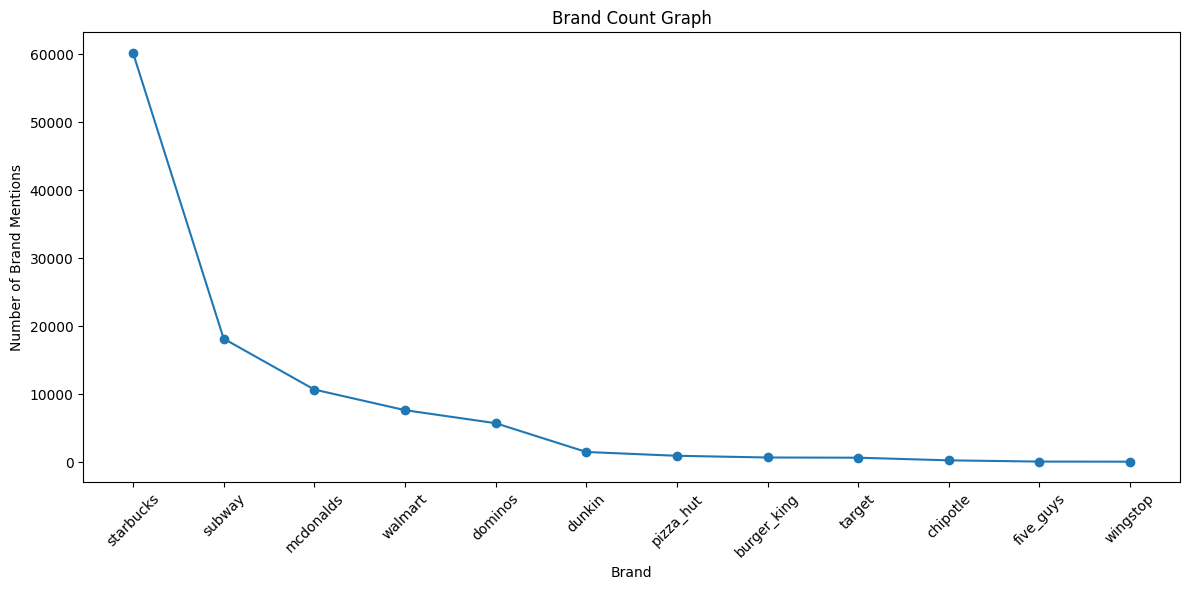

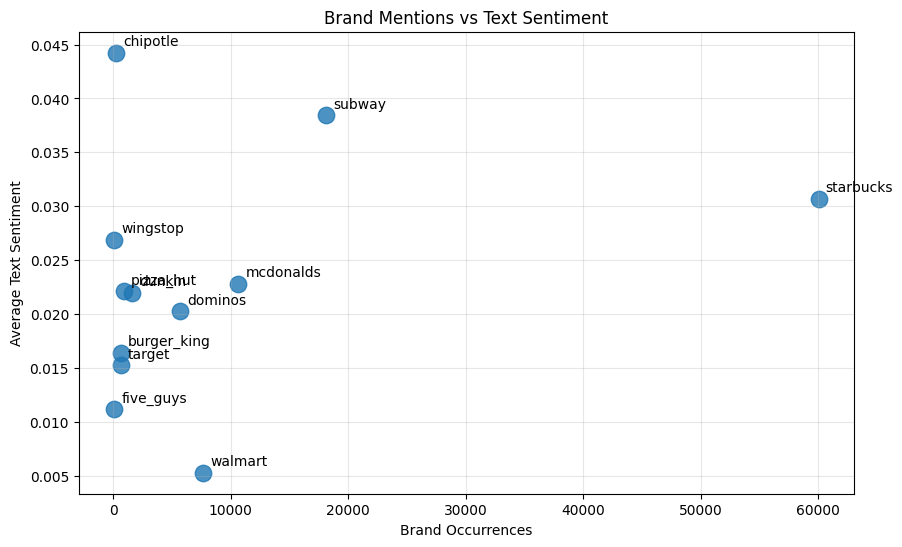

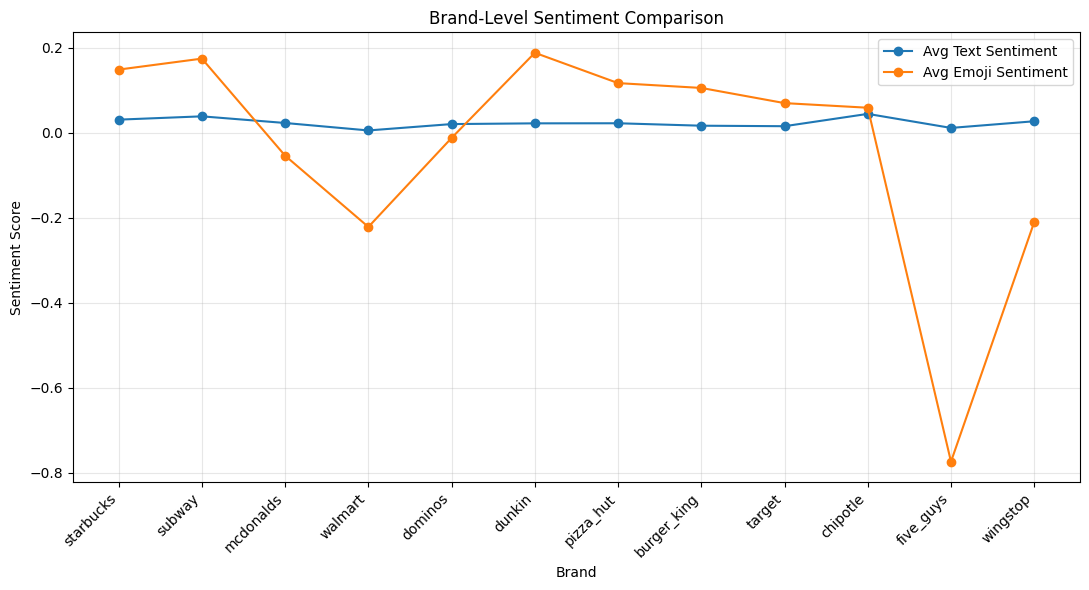

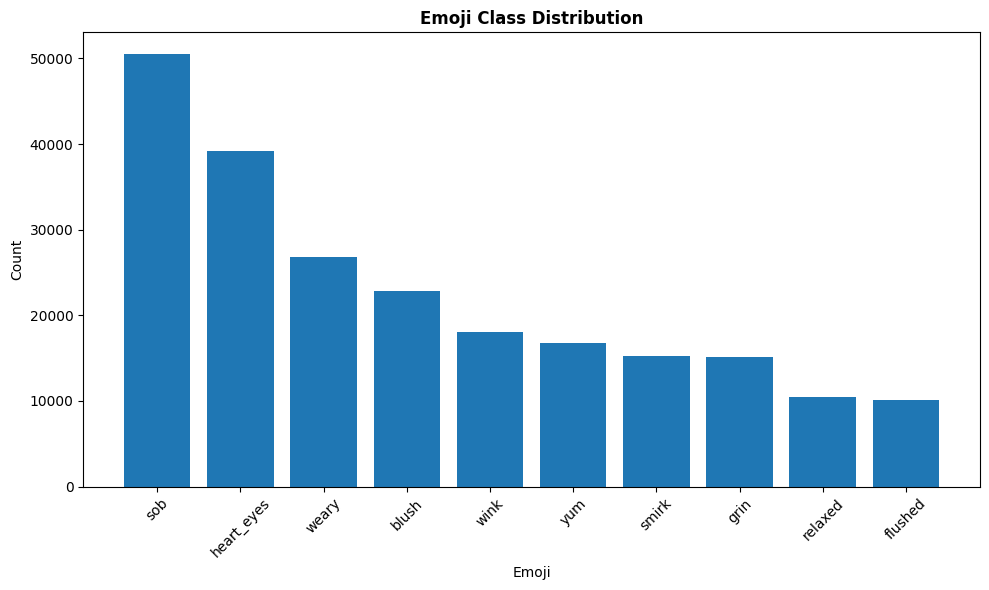

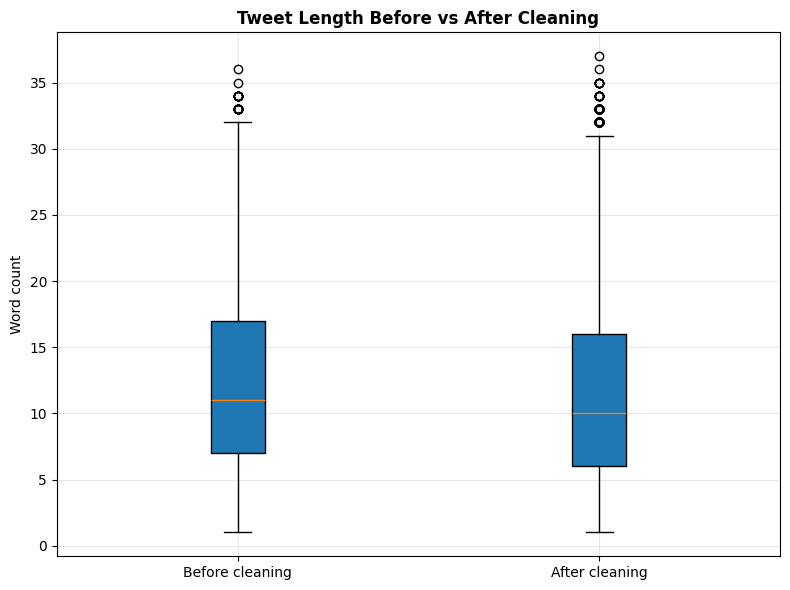


=== Cleaning Impact ===
Average word count before cleaning: 12.13
Average word count after cleaning:  11.23
Average decrease in words:          0.89
Percent decrease after cleaning:    7.38%


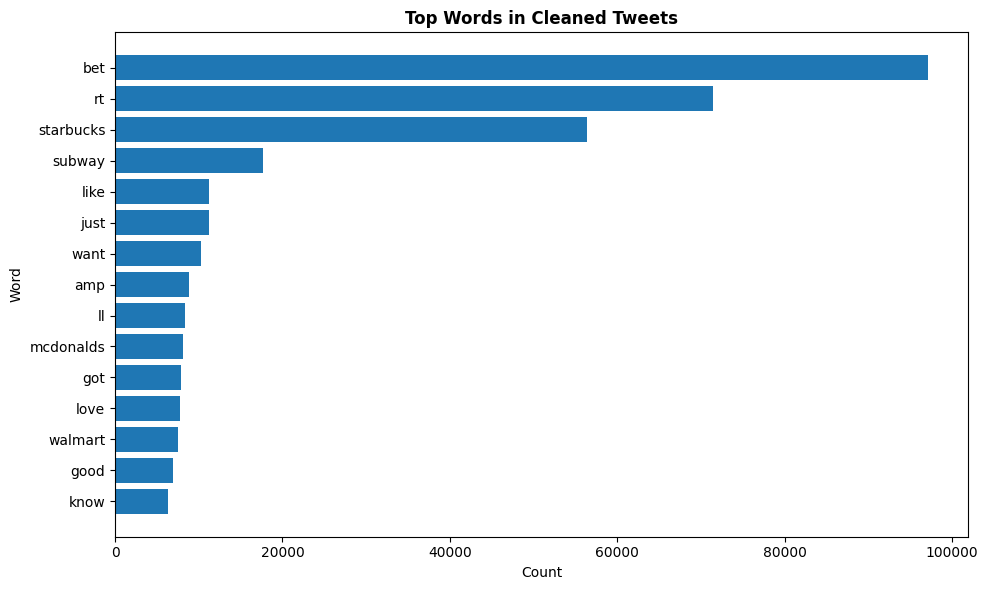

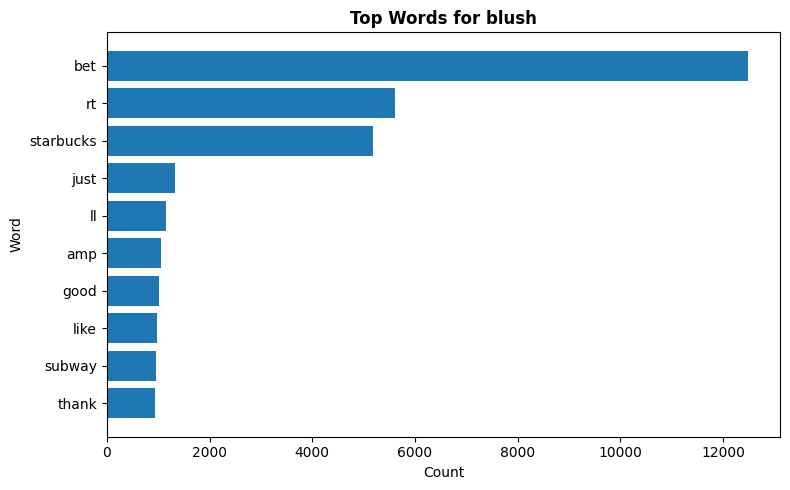

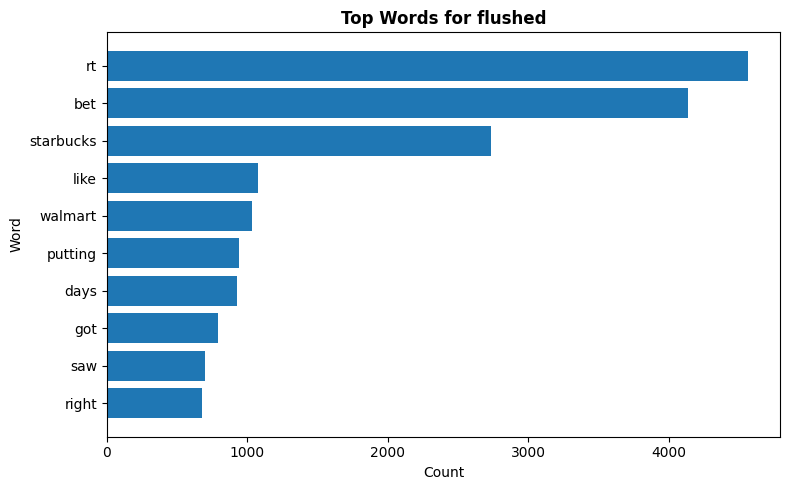

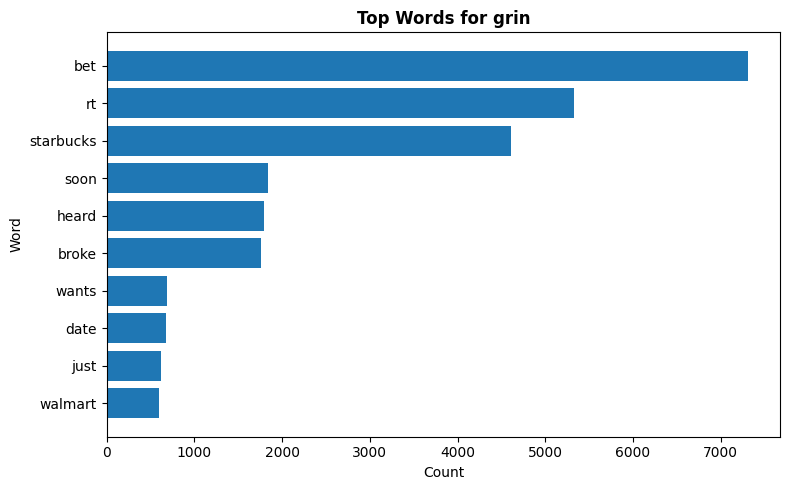

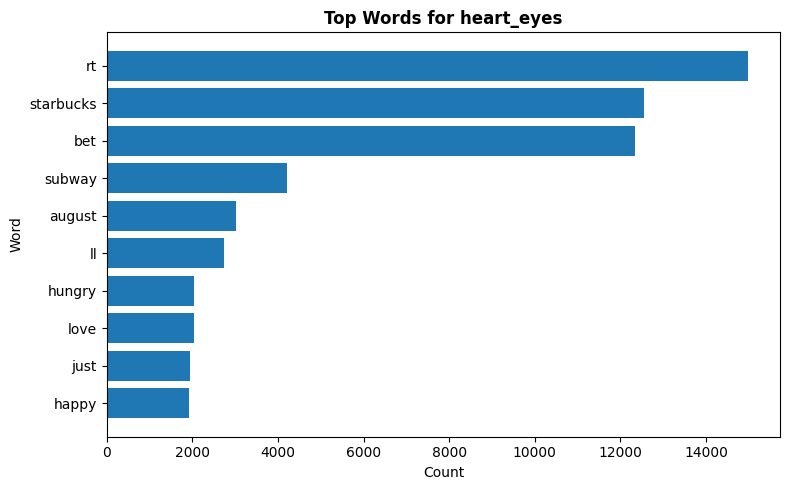

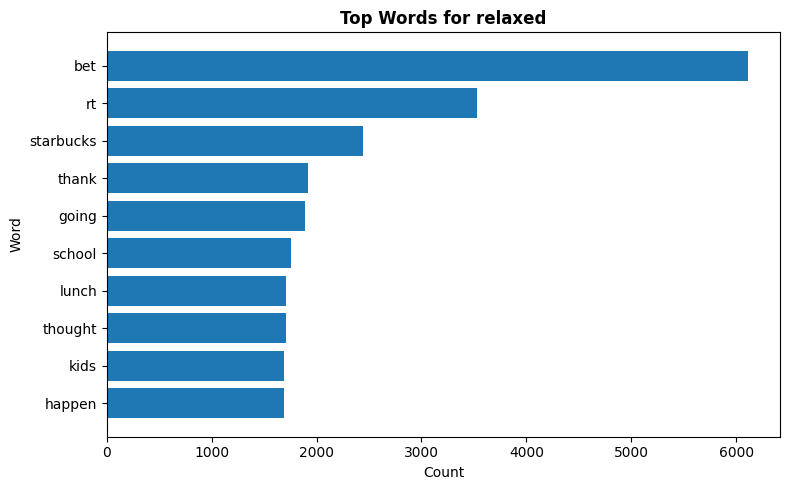

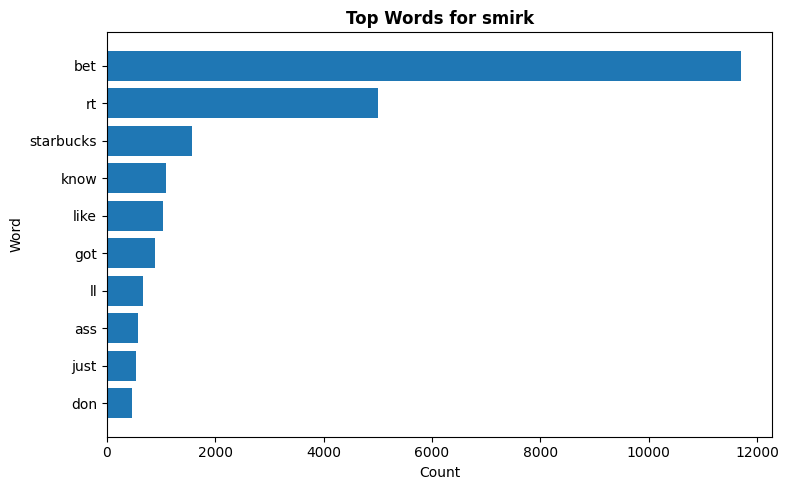

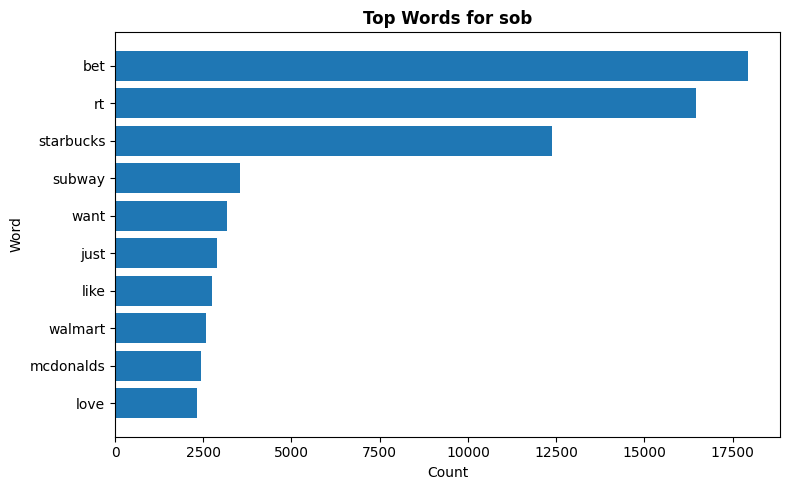

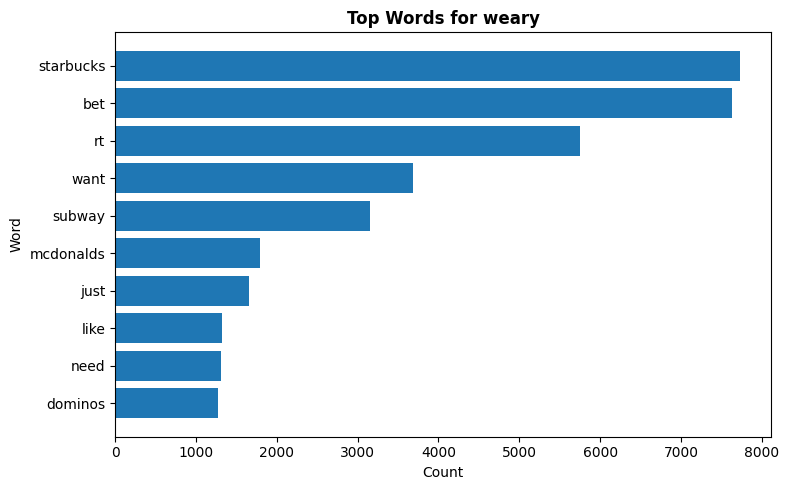

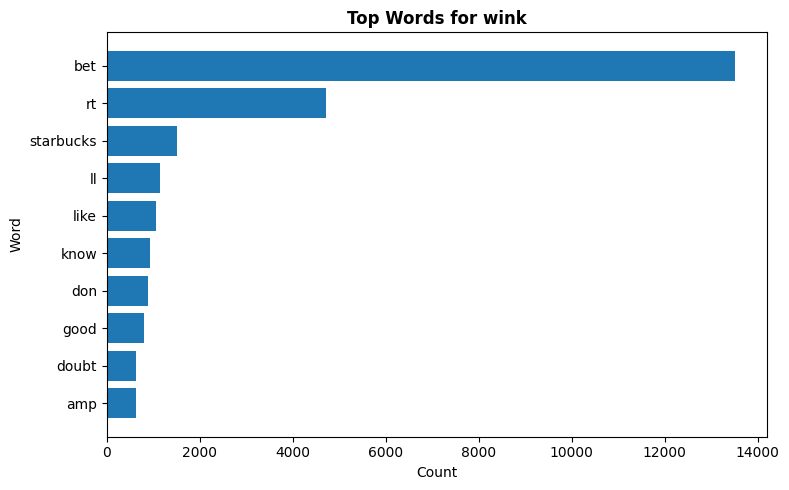

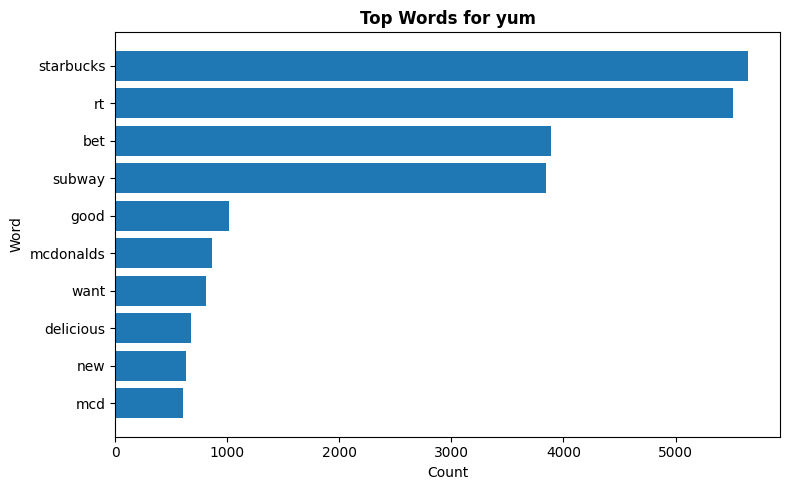

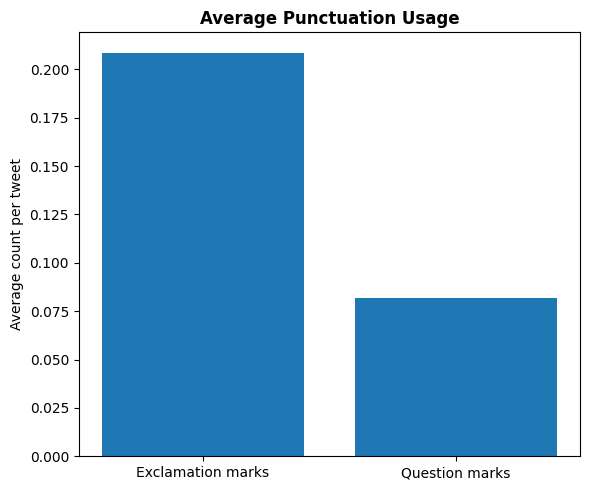

In [20]:
if __name__ == "__main__":
    run_all_visualizations()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=62b91583-1382-466d-9446-3dc5e725c312' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>